<a href="https://colab.research.google.com/github/smal3iutre2/washu-5509/blob/main/Project/baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nuscenes-devkit

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!tar -xf /content/drive/MyDrive/v1.0-mini.tgz -C /content/data/sets/nuscenes

In [5]:
!ls drive/MyDrive/

 26spring
'Application for Global Internship Program - Minghe Liu.gdoc'
'Colab Notebooks'
'Engineering Processes & Agile.gdoc'
 HW2.gdoc
 Jobs
'Lab - Configure your Attack Lab and Shellshock.gdoc'
'Progress report week 13.gdoc'
'Summer 2026 Intern AI Reflection Take-home Assignment.gdoc'
 Untitled0.ipynb
'Untitled document (1).gdoc'
'Untitled document (2).gdoc'
'Untitled document (3).gdoc'
'Untitled document (4).gdoc'
'Untitled document (5).gdoc'
'Untitled document.gdoc'
'Untitled presentation.gslides'
'Untitled spreadsheet (1).gsheet'
'Untitled spreadsheet (2).gsheet'
'Untitled spreadsheet.gsheet'
 v1.0-mini.tgz
 WashU
 yelp-project


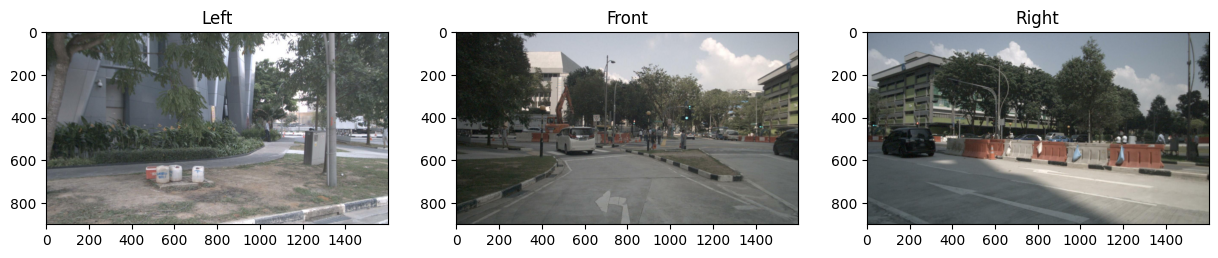

In [8]:
from nuscenes.nuscenes import NuScenes
import cv2
import matplotlib.pyplot as plt

# 1. 初始化 (请确保路径指向你解压后的目录)
nusc = NuScenes(version='v1.0-mini', dataroot='/content/data/sets/nuscenes', verbose=False)

# 2. 选取一个样本 (Sample)
my_sample = nusc.sample[10] # 选第10个样本，通常包含较清楚的道路场景

def get_image_path(sensor_name):
    data_token = my_sample['data'][sensor_name]
    return nusc.get_sample_data(data_token)[0]

# 获取左、中、右三个视角的路径
img_left_path = get_image_path('CAM_FRONT_LEFT')
img_mid_path = get_image_path('CAM_FRONT')
img_right_path = get_image_path('CAM_FRONT_RIGHT')

# 读取图片
img_left = cv2.imread(img_left_path)
img_mid = cv2.imread(img_mid_path)
img_right = cv2.imread(img_right_path)

# 预览一下
plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB)); plt.title('Left')
plt.subplot(132); plt.imshow(cv2.cvtColor(img_mid, cv2.COLOR_BGR2RGB)); plt.title('Front')
plt.subplot(133); plt.imshow(cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB)); plt.title('Right')
plt.show()

In [9]:
# 初始化 SIFT
sift = cv2.SIFT_create()

# 提取特征点
kp1, des1 = sift.detectAndCompute(img_mid, None)
kp2, des2 = sift.detectAndCompute(img_right, None)

# 特征匹配 (使用 FLANN)
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

# 筛选好的匹配点
good = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good.append(m)

print(f"在 Front 和 Right 之间找到了 {len(good)} 个匹配点")

在 Front 和 Right 之间找到了 70 个匹配点


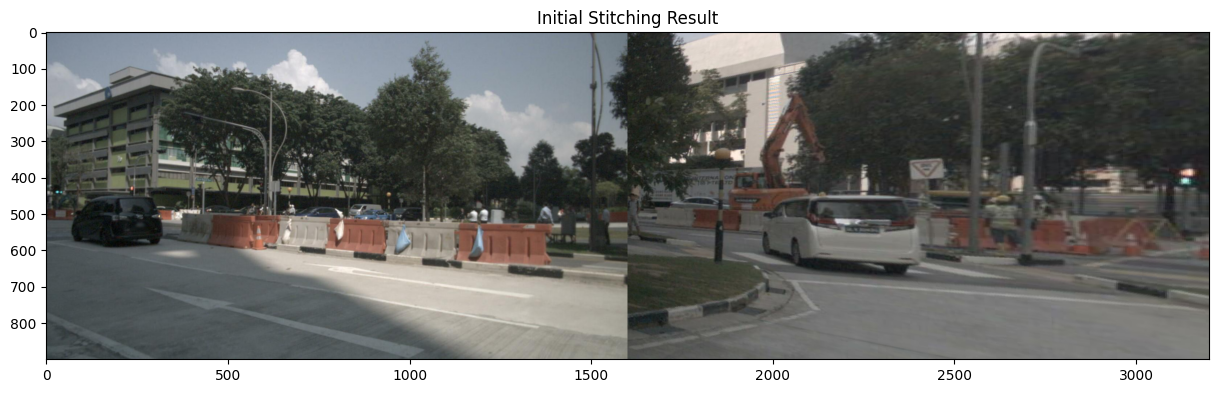

In [10]:
import numpy as np

if len(good) > 10:
    # 1. 提取匹配点的坐标 [cite: 47]
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)

    # 2. 计算单应性矩阵 M
    # M 可以把 Front 的坐标映射到 Right
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # 3. 图像变换 (Warping) [cite: 47]
    # 我们以中间图为基准，将右图拼上去。为了防止图片跑出边界，我们需要一个大画布
    h, w = img_mid.shape[:2]
    # 简单的拼接演示：创建一个两倍宽度的画布
    result = cv2.warpPerspective(img_mid, M, (w*2, h), flags=cv2.WARP_INVERSE_MAP)

    # 4. 叠加 [cite: 47]
    result[0:h, 0:w] = img_right # 这只是初级叠加，后续你需要处理重叠区域

    plt.figure(figsize=(15,10))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title("Initial Stitching Result")
    plt.show()
else:
    print("匹配点太少，无法计算矩阵")

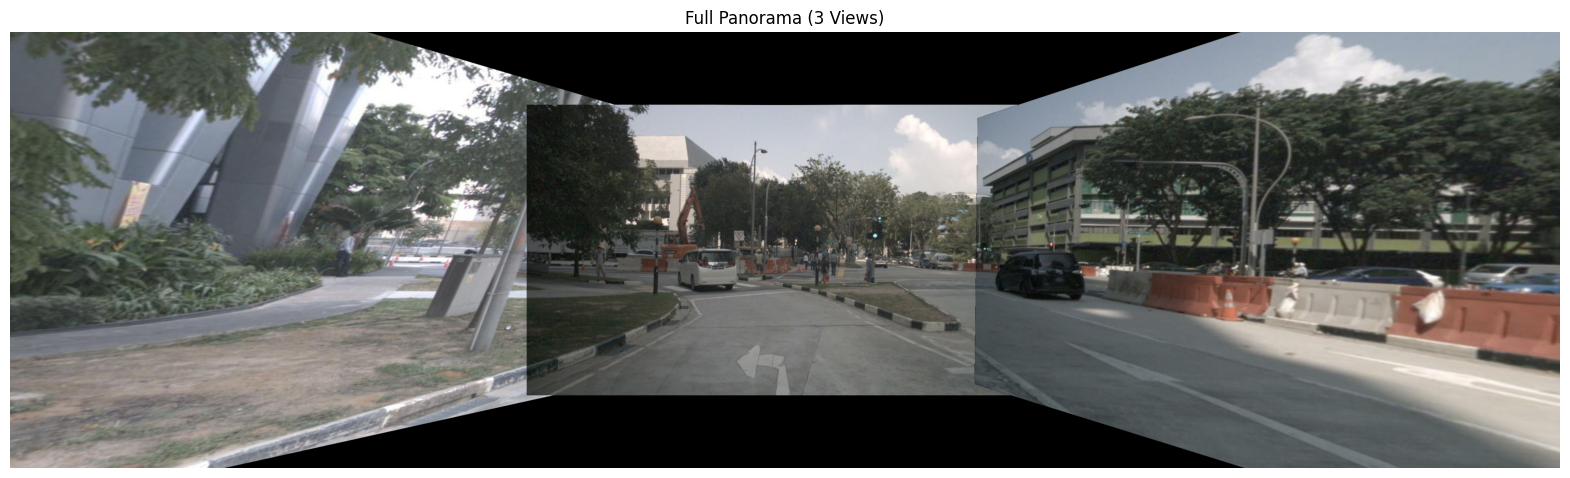

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def stitch_three_images(img_l, img_m, img_r):
    # 1. 初始化 SIFT
    sift = cv2.SIFT_create()

    # 提取特征点和描述符
    kp_l, des_l = sift.detectAndCompute(img_l, None)
    kp_m, des_m = sift.detectAndCompute(img_m, None)
    kp_r, des_r = sift.detectAndCompute(img_r, None)

    # 2. 特征匹配函数 (FLANN)
    def get_homography(des1, des2, kp1, kp2):
        FLANN_INDEX_KDTREE = 1
        index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
        search_params = dict(checks=50)
        flann = cv2.FlannBasedMatcher(index_params, search_params)
        matches = flann.knnMatch(des1, des2, k=2)

        good = [m for m, n in matches if m.distance < 0.7 * n.distance]
        if len(good) > 10:
            src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
            # 注意：我们要把左右图变换到中间图的平面
            M, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
            return M
        return None

    # 3. 计算单应性矩阵 (把 Left 和 Right 都映射到 Mid)
    # [cite: 47, 69]
    M_left_to_mid = get_homography(des_l, des_m, kp_l, kp_m)
    M_right_to_mid = get_homography(des_r, des_m, kp_r, kp_m)

    if M_left_to_mid is None or M_right_to_mid is None:
        print("特征匹配点不足，无法拼接！")
        return None

    # 4. 创建大画布
    # 假设最终全景图宽度是单张图的 3 倍，高度稍微增加以容纳旋转
    h, w = img_m.shape[:2]
    canvas_w = w * 3
    canvas_h = h * 1.5

    # 定义平移矩阵，让中间图出现在画布的正中心
    offset_x = w
    offset_y = h // 4
    T = np.float32([[1, 0, offset_x], [0, 1, offset_y], [0, 0, 1]])

    # 5. 执行透视变换 [cite: 48, 57]
    # 先把左右矩阵结合平移矩阵
    M_l_final = T @ M_left_to_mid
    M_r_final = T @ M_right_to_mid
    M_m_final = T # 中间图只做平移

    # 变形图像
    result_l = cv2.warpPerspective(img_l, M_l_final, (canvas_w, int(canvas_h)))
    result_r = cv2.warpPerspective(img_r, M_r_final, (canvas_w, int(canvas_h)))
    result_m = cv2.warpPerspective(img_m, M_m_final, (canvas_w, int(canvas_h)))

    # 6. 简单的图像融合 (覆盖式)
    # 在进阶阶段，你可以使用线性加权融合来消除接缝 [cite: 31]
    output = result_l.copy()

    # 找出非黑色区域并覆盖
    mask_m = np.any(result_m != 0, axis=-1)
    output[mask_m] = result_m[mask_m]

    mask_r = np.any(result_r != 0, axis=-1)
    output[mask_r] = result_r[mask_r]

    return output

# --- 运行部分 ---
# 假设你已经定义好了 img_left, img_mid, img_right
final_panorama = stitch_three_images(img_left, img_mid, img_right)

if final_panorama is not None:
    plt.figure(figsize=(20, 10))
    plt.imshow(cv2.cvtColor(final_panorama, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Full Panorama (3 Views)")
    plt.show()

In [13]:
def transform_point_to_bev(point, stitching_M, ipm_M):
    """
    将原始图像中的点转换到 BEV 坐标系
    point: [x, y]
    stitching_M: 拼接矩阵 (如 M_right_to_mid)
    ipm_M: 逆透视映射矩阵
    """
    # 1. 转换到全景图坐标 (Homogeneous coordinates)
    p = np.array([point[0], point[1], 1]).reshape(3, 1)
    p_panorama = stitching_M @ p
    p_panorama /= p_panorama[2] # 归一化

    # 2. 转换到 BEV 坐标
    p_bev = ipm_M @ p_panorama
    p_bev /= p_bev[2]

    return int(p_bev[0]), int(p_bev[1])

In [14]:
# 假设你在全景图中找到了这四个点（需要根据你的图片结果微调）
# 点的顺序：左上, 右上, 右下, 左下
src_pts = np.float32([
    [1200, 600], # 远处左
    [2000, 600], # 远处右
    [2800, 900], # 近处右
    [400, 900]   # 近处左
])

# 定义这四个点在 BEV 地图中应该出现的位置（一个正方形/长方形）
# 假设 BEV 地图大小为 800x800
dst_pts = np.float32([
    [200, 200],
    [600, 200],
    [600, 600],
    [200, 600]
])

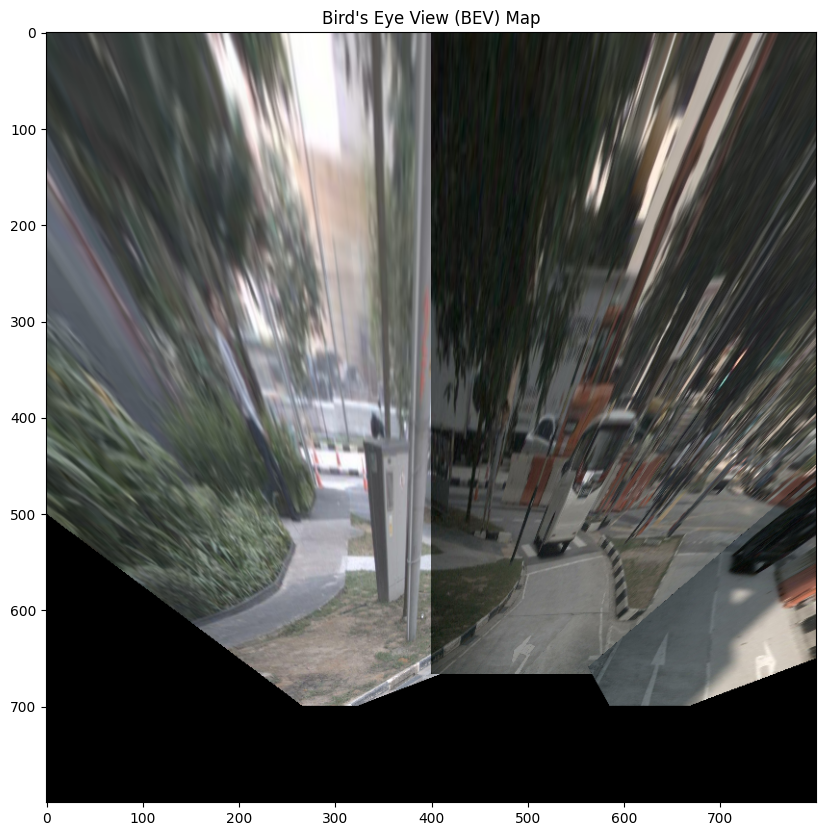

In [15]:
# 1. 计算 IPM 变换矩阵
M_ipm = cv2.getPerspectiveTransform(src_pts, dst_pts)

# 2. 对全景图进行变换
bev_height, bev_width = 800, 800
bev_map = cv2.warpPerspective(final_panorama, M_ipm, (bev_width, bev_height))

# 3. 显示结果
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(bev_map, cv2.COLOR_BGR2RGB))
plt.title("Bird's Eye View (BEV) Map")
plt.show()